# 5.1 — Instrumentos y convenciones: depósitos, FRAs, futuros, swaps, OIS

Hasta aquí el currículum trabajó con un solo activo riesgoso y una tasa libre de riesgo constante — suficiente para derivar Black-Scholes, Monte Carlo y diferencias finitas, pero ningún mercado real cotiza "$r=5\%$ para siempre". Lo que el mercado cotiza son **instrumentos de tasa**: depósitos, FRAs, futuros, swaps, cada uno con su convención de día-conteo y su mecánica de liquidación propia, y de la colección completa de esas cotizaciones hay que **reconstruir** la curva de descuento (5.2) antes de poder valuar cualquier otra cosa que dependa de tasas.

Este notebook no bootstrapea nada todavía — es el vocabulario y la aritmética que 5.2 va a necesitar. La pregunta que estructura todo: ¿cuánto vale un flujo de caja futuro, y qué convención dicta cómo se cuenta el tiempo hasta que llega? La respuesta parece trivial hasta que dos convenciones distintas sobre las mismas fechas dan números medibles distintos, y de eso trata la primera sección.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df
from qflib.plotting import apply_style

apply_style()

print("Curva 'verdadera' de referencia para todo M5-M7: Nelson-Siegel con los parametros por defecto")
print(f"P(0, 1) = {nelson_siegel_df(1.0):.6f}  |  P(0, 5) = {nelson_siegel_df(5.0):.6f}  |  "
      f"P(0, 10) = {nelson_siegel_df(10.0):.6f}")
print("Sin Monte Carlo en este notebook -- todo es aritmetica de fechas y flujos.")

Curva 'verdadera' de referencia para todo M5-M7: Nelson-Siegel con los parametros por defecto
P(0, 1) = 0.961814  |  P(0, 5) = 0.801800  |  P(0, 10) = 0.638058
Sin Monte Carlo en este notebook -- todo es aritmetica de fechas y flujos.


## 1. Convenciones de día-conteo

Una tasa cotizada no significa nada sin especificar **cómo se cuenta el tiempo** entre dos fechas. Las tres convenciones estándar del mercado de tasas:

$$
\tau_{\text{Act}/360}(d_1,d_2) = \frac{d_2-d_1}{360}, \qquad
\tau_{\text{Act}/365F}(d_1,d_2) = \frac{d_2-d_1}{365}, \qquad
\tau_{30/360}(d_1,d_2) = \frac{360(y_2-y_1)+30(m_2-m_1)+(\hat d_2-\hat d_1)}{360},
$$

donde $d_2-d_1$ son días calendario reales y $\hat d_i$ es el día del mes ajustado por la regla "Bond Basis" ($\hat d_1=30$ si $d_1$ cae el 31; $\hat d_2=30$ si $d_2$ cae el 31 **y** $\hat d_1=30$). `Act/360` es el estándar del mercado de dinero (depósitos, FRAs, la mayoría de swaps flotantes en USD/EUR); `Act/365 Fixed` aparece en GBP y en muchos contratos de derivados; `30/360` es el estándar histórico de bonos, donde cada mes "vale" exactamente 30 días por convención, sin importar si tiene 28, 30 o 31.

**Por qué importa numéricamente:** las tres cuentan el mismo periodo calendario con fracciones de año ligeramente distintas, y esa fracción multiplica directamente la tasa en cualquier fórmula de descuento — la convención equivocada no es un error conceptual sutil, es un error de valuación de magnitud comparable al de una tasa mal cotizada.

In [2]:
def act360(d1, d2):
    '''Actual/360 day count: (d2-d1) calendar days / 360.'''
    return (d2 - d1).days / 360.0


def act365f(d1, d2):
    '''Actual/365 Fixed day count: (d2-d1) calendar days / 365.'''
    return (d2 - d1).days / 365.0


def thirty360_bond(d1, d2):
    '''30/360 Bond Basis day count (ISDA), with the standard 31st-of-the-month adjustment.'''
    d1d, d1m, d1y = d1.day, d1.month, d1.year
    d2d, d2m, d2y = d2.day, d2.month, d2.year
    if d1d == 31:
        d1d = 30
    if d2d == 31 and d1d == 30:
        d2d = 30
    return (360 * (d2y - d1y) + 30 * (d2m - d1m) + (d2d - d1d)) / 360.0


import datetime as dt

d1, d2 = dt.date(2027, 3, 15), dt.date(2027, 9, 20)
notional, rate = 1_000_000.0, 0.045

print(f"Periodo: {d1} a {d2} ({(d2-d1).days} dias calendario)")
print(f"{'convencion':>14} | {'fraccion de ano':>15} | {'interes simple (rate=4.5%)':>28}")
print("-" * 64)
for name, tau in [("Act/360", act360(d1, d2)), ("Act/365F", act365f(d1, d2)),
                  ("30/360 Bond", thirty360_bond(d1, d2))]:
    print(f"{name:>14} | {tau:>15.6f} | {notional * rate * tau:>28,.2f}")

Periodo: 2027-03-15 a 2027-09-20 (189 dias calendario)
    convencion | fraccion de ano |   interes simple (rate=4.5%)
----------------------------------------------------------------
       Act/360 |        0.525000 |                    23,625.00
      Act/365F |        0.517808 |                    23,301.37
   30/360 Bond |        0.513889 |                    23,125.00


## 2. Composición de tasas, depósitos y FRAs

**Composición.** Una tasa cotizada puede ser simple ($1+r\tau$), compuesta discreta ($(1+r/n)^{n\tau}$) o continua ($e^{r\tau}$, la convención que usa todo Black-Scholes/M0-M4). El mercado de dinero cotiza **simple**: un depósito a plazo $\tau$ paga $1+L\tau$ al vencimiento por cada unidad invertida, con $L$ la tasa cotizada bajo la convención de día-conteo del mercado (típicamente `Act/360`). El precio hoy de recibir $1$ en $T$ es entonces $P(0,T)=\dfrac1{1+L(0,T)\,T}$ — la definición misma de discount factor en términos de una tasa de mercado.

**FRA (Forward Rate Agreement).** Un contrato para fijar hoy la tasa que se pagará sobre un depósito futuro entre $T_1$ y $T_2$. Su tasa **par** (la que hace el contrato valer cero hoy) se deriva por réplica pura, sin ningún modelo: comprar un bono que paga $1$ en $T_1$ y venderlo re-invertido a la tasa forward hasta $T_2$ debe costar lo mismo que comprar directamente un bono que paga en $T_2$ — de ahí
$$
1 + L(T_1,T_2)\,\tau = \frac{P(0,T_1)}{P(0,T_2)} \qquad\Longrightarrow\qquad \boxed{L(T_1,T_2) = \frac{1}{\tau}\left(\frac{P(0,T_1)}{P(0,T_2)}-1\right)},
$$
con $\tau=\tau(T_1,T_2)$ en la convención del mercado del FRA. Nótese que esto es **exactamente** el mismo argumento de no-arbitraje que dedujo el forward $F_t=S_te^{(r-q)(T-t)}$ en 3.1 — un FRA es el forward de una tasa, y la fórmula sale de la misma réplica estática con bonos en vez de con el activo y la cuenta bancaria.

El payoff de un FRA con nocional $N$ y strike $K$, si se liquida en $T_2$ (al vencimiento del periodo), es $N(L(T_1,T_2)-K)\tau$; en la práctica casi todos los FRA liquidan **en $T_1$**, descontando ese flujo un periodo: $\dfrac{N(L-K)\tau}{1+L\tau}$. Con $K=L(T_1,T_2)$ (la tasa par) el payoff es idénticamente cero en cualquiera de las dos convenciones — la comprobación numérica de la Demo 1.

In [3]:
T1, T2 = 0.5, 1.0
P1, P2 = nelson_siegel_df(T1), nelson_siegel_df(T2)
tau = T2 - T1
L_fwd = (P1 / P2 - 1.0) / tau

print(f"P(0,{T1}) = {P1:.6f}   P(0,{T2}) = {P2:.6f}")
print(f"tasa forward FRA L({T1},{T2}) = {L_fwd:.6f}  ({L_fwd:.4%})")

# Replica: financiar un deposito de 1 unidad hoy (cuesta P1), reinvertir a L_fwd hasta T2 (vale (1+L_fwd*tau)*P2 hoy)
replicated_value_today = -P1 + (1.0 + L_fwd * tau) * P2
print(f"\nValor hoy de 'financiar deposito en T1, reinvertir a L_fwd hasta T2' menos su costo: "
      f"{replicated_value_today:.2e}  (debe ser 0 -- es la definicion de tasa par)")
assert abs(replicated_value_today) < 1e-12

# Payoff del FRA a K=L_fwd, en las dos convenciones de liquidacion
K = L_fwd
notional = 1.0
payoff_at_T2 = notional * (L_fwd - K) * tau
payoff_at_T1 = notional * (L_fwd - K) * tau / (1.0 + L_fwd * tau)
print(f"payoff del FRA a K=L_fwd, liquidado en T2 = {payoff_at_T2:.2e}")
print(f"payoff del FRA a K=L_fwd, liquidado en T1 = {payoff_at_T1:.2e}   (ambos cero por construccion)")

P(0,0.5) = 0.981566   P(0,1.0) = 0.961814
tasa forward FRA L(0.5,1.0) = 0.041073  (4.1073%)

Valor hoy de 'financiar deposito en T1, reinvertir a L_fwd hasta T2' menos su costo: 0.00e+00  (debe ser 0 -- es la definicion de tasa par)
payoff del FRA a K=L_fwd, liquidado en T2 = 0.00e+00
payoff del FRA a K=L_fwd, liquidado en T1 = 0.00e+00   (ambos cero por construccion)


## 3. Futuros de tasa: el ajuste de convexidad

Un futuro sobre tasa (ED futures histórico, hoy SOFR futures) parece cotizar lo mismo que un FRA — una tasa forward — pero **no es exactamente igual**, y la diferencia tiene nombre: **ajuste de convexidad**. La razón estructural es la misma que separó $\mathbb{Q}$ de $\mathbb{Q}^T$ en 3.5: un futuro se marca a mercado **diariamente** (las ganancias/pérdidas se liquidan cada día bajo la cuenta bancaria, la medida $\mathbb{Q}$), mientras que el forward implícito en un FRA vive naturalmente bajo la medida forward $\mathbb{Q}^{T_2}$. Cuando el numerario no es el mismo, el valor esperado de la misma variable aleatoria (la tasa a $T_1$) difiere entre las dos medidas — y esa diferencia es precisamente la convexidad.

Bajo un modelo de tasa corta con volatilidad $\sigma$ (Hull-White, que M6 va a derivar en detalle), Hull (2018 cap. 6) da la aproximación estándar
$$
\text{tasa futuro} - \text{tasa forward} \;\approx\; \tfrac12\sigma^2\,T_1T_2,
$$
que crece con el **producto** de los dos vencimientos: un futuro que fija una tasa muy en el futuro ($T_1$ grande) sobre un periodo que además termina tarde ($T_2$ grande) acumula mucha más incertidumbre de marcado diario que uno de corto plazo — de ahí que el ajuste sea prácticamente irrelevante en el tramo corto de la curva y se vuelva material (varias decenas de puntos base) más allá de 5-7 años. La fórmula cerrada exacta bajo Hull-White queda para 6.2, una vez derivado el modelo; aquí basta la aproximación y su forma cualitativa.

   T1 |    T2 |  ajuste de convexidad (bp)
--------------------------------------------
 1.00 |  1.25 |                      0.900
 3.00 |  3.25 |                      7.020
 5.00 |  5.25 |                     18.900
 9.00 |  9.25 |                     59.940


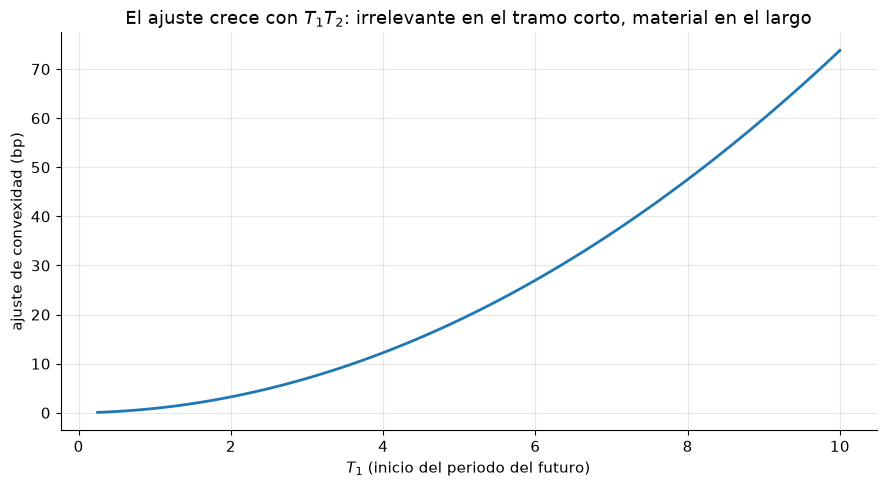

In [4]:
def convexity_adjustment(T1, T2, sigma):
    '''Futures-forward convexity adjustment, Hull's approximation (Section 3): 0.5*sigma^2*T1*T2.'''
    return 0.5 * sigma**2 * T1 * T2


sigma_example = 0.012   # vol anual tipica de la tasa corta, orden de magnitud de mercado
print(f"{'T1':>5} | {'T2':>5} | {'ajuste de convexidad (bp)':>26}")
print("-" * 44)
for T1_f, T2_f in [(1.0, 1.25), (3.0, 3.25), (5.0, 5.25), (9.0, 9.25)]:
    adj_bp = convexity_adjustment(T1_f, T2_f, sigma_example) * 1e4
    print(f"{T1_f:>5.2f} | {T2_f:>5.2f} | {adj_bp:>26.3f}")

T1_grid = np.linspace(0.25, 10.0, 100)
adj_grid = convexity_adjustment(T1_grid, T1_grid + 0.25, sigma_example) * 1e4

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T1_grid, adj_grid, lw=2)
ax.set_xlabel("$T_1$ (inicio del periodo del futuro)"); ax.set_ylabel("ajuste de convexidad (bp)")
ax.set_title("El ajuste crece con $T_1 T_2$: irrelevante en el tramo corto, material en el largo")
plt.tight_layout()
plt.show()

## 4. Swaps y OIS

**Swap fijo-flotante.** El instrumento más líquido del mercado de tasas: una parte paga una tasa fija $K$ sobre un nocional en fechas periódicas, la otra paga una tasa flotante (históricamente Libor, hoy típicamente una tasa overnight compuesta) resetada cada periodo. Su **tasa par** — la que hace el swap valer cero al inicio — se deriva de la misma manera que la del FRA: la pata flotante, sin riesgo de crédito ni spread, vale exactamente $1-P(0,T_n)$ (réplica: recibir la tasa flotante cada periodo es económicamente idéntico a invertir a la tasa corta y reinvertir, telescópico hasta el nocional final), así que
$$
K^{\text{par}} = \frac{1-P(0,T_n)}{\sum_{i=1}^n\tau_iP(0,T_i)},
$$
con el denominador llamado la **anualidad** (annuity) del swap — la misma cantidad que en 5.5 va a resultar ser el DV01 a primer orden.

**OIS (overnight indexed swap).** La pata flotante paga el **compuesto geométrico diario** de una tasa overnight $o_i$ (Fed Funds/SOFR, ESTR, etc.) sobre el periodo, no una tasa simple observada una sola vez:
$$
1+L_{\text{OIS}}(0,T)\cdot\tau = \prod_{i=1}^{m}(1+o_i\cdot\delta_i),
$$
con $\delta_i$ la fracción de un día. Conviene separar dos efectos que se confunden fácilmente. El primero es puramente **determinista** y aparece incluso si $o_i=r$ es constante todo el periodo: componer $r/360$ durante $360$ días da $(1+r/360)^{360}$, que **no** iguala $1+r$. Expandiendo, $(1+r/360)^{360}\approx e^{r}\approx 1+r+\tfrac12r^2$, así que la tasa compuesta total excede a la simple en $\approx\tfrac12r^2$ — con $r=4\%$ eso son $\approx8$ puntos base, nada despreciable. Es la misma aritmética que separa interés simple de interés compuesto en cualquier curso de finanzas, y no depende de que $o_i$ varíe. El segundo efecto, más sutil y genuinamente el análogo de la Sección 3, es la **convexidad de Jensen** que aparece cuando $o_i$ sí varía estocásticamente día a día: $\mathbb{E}[\prod(1+o_i\delta_i)]$ no es lo mismo que $\prod(1+\mathbb{E}[o_i]\delta_i)$, y esa brecha adicional (de segundo orden en la volatilidad del overnight, típicamente mucho menor que el efecto determinista salvo en periodos largos y muy volátiles) es la que de verdad comparte familia con la convexidad futuro-forward.

In [5]:
def par_swap_rate_from_curve(curve_fn, payment_times):
    '''Par fixed rate of a vanilla annual swap, single-curve (Section 4).'''
    times = np.asarray(payment_times, dtype=float)
    dfs = curve_fn(times)
    tau = np.diff(np.concatenate([[0.0], times]))
    annuity = np.sum(tau * dfs)
    return (1.0 - dfs[-1]) / annuity


swap_5y = par_swap_rate_from_curve(nelson_siegel_df, np.arange(1, 6))
swap_10y = par_swap_rate_from_curve(nelson_siegel_df, np.arange(1, 11))
print(f"Swap par 5Y  = {swap_5y:.6f}  ({swap_5y:.4%})")
print(f"Swap par 10Y = {swap_10y:.6f}  ({swap_10y:.4%})")

# OIS: compuesto geometrico diario de una tasa overnight CONSTANTE (Act/360, 360 accruals -- un ano completo)
overnight_rate = 0.04
n_accruals = 360
daily_factor = (1.0 + overnight_rate / 360.0) ** n_accruals
ois_compound_rate = daily_factor - 1.0   # tasa TOTAL del periodo (un ano), no anualizada por separado
simple_equivalent = overnight_rate
gap_bp = (ois_compound_rate - simple_equivalent) * 1e4
print(f"overnight constante = {overnight_rate:.4%}")
print(f"compuesto diario (360 accruals de r/360) = {ois_compound_rate:.6%}")
print(f"diferencia vs simple = {gap_bp:.3f} bp  (prediccion r^2/2 = {0.5*overnight_rate**2*1e4:.3f} bp)")
print("Efecto deterministico, presente aunque el overnight sea perfectamente constante -- "
      "no es 'poco importante', son casi 10bp para una tasa de 4%.")
assert abs(gap_bp - 0.5 * overnight_rate**2 * 1e4) < 0.1

Swap par 5Y  = 0.045008  (4.5008%)
Swap par 10Y = 0.045786  (4.5786%)
overnight constante = 4.0000%
compuesto diario (360 accruals de r/360) = 4.080846%
diferencia vs simple = 8.085 bp  (prediccion r^2/2 = 8.000 bp)
Efecto deterministico, presente aunque el overnight sea perfectamente constante -- no es 'poco importante', son casi 10bp para una tasa de 4%.


## 5. Validación

1. **Día-conteo**: las tres convenciones propias vs `ql.Actual360`, `ql.Actual365Fixed`, `ql.Thirty360(BondBasis)` sobre 10 pares de fechas aleatorias, `atol=1e-9` (son fracciones racionales; el margen cubre el redondeo de `datetime`/`Date` en el borde de meses).
2. **FRA**: la réplica depósito-a-FRA vale exactamente cero, `atol=1e-12`; el payoff del FRA a la tasa par es cero en ambas convenciones de liquidación, `atol=1e-12`.
3. **Convexidad**: el ajuste crece estrictamente con $T_1$ (assert de monotonía, no de un valor puntual — la fórmula es una aproximación, no hay "verdad" externa contra la cual comparar un número exacto aquí).

In [6]:
import QuantLib as ql

eval_date_check = ql.Date(1, 1, 2026)
rng_check = np.random.default_rng(3)
mismatches = 0
for _ in range(10):
    off1 = int(rng_check.integers(0, 3000))
    off2 = off1 + int(rng_check.integers(1, 900))
    d_ql_1, d_ql_2 = eval_date_check + off1, eval_date_check + off2
    d_py_1 = dt.date(d_ql_1.year(), d_ql_1.month(), d_ql_1.dayOfMonth())
    d_py_2 = dt.date(d_ql_2.year(), d_ql_2.month(), d_ql_2.dayOfMonth())

    diffs = [
        abs(act360(d_py_1, d_py_2) - ql.Actual360().yearFraction(d_ql_1, d_ql_2)),
        abs(act365f(d_py_1, d_py_2) - ql.Actual365Fixed().yearFraction(d_ql_1, d_ql_2)),
        abs(thirty360_bond(d_py_1, d_py_2) - ql.Thirty360(ql.Thirty360.BondBasis).yearFraction(d_ql_1, d_ql_2)),
    ]
    if max(diffs) > 1e-9:
        mismatches += 1
print(f"Day-count: {10 - mismatches} de 10 pares coinciden con QuantLib dentro de atol=1e-9")
assert mismatches == 0

print(f"\nReplica FRA = {abs(replicated_value_today):.2e} (atol 1e-12? {abs(replicated_value_today) < 1e-12})")
assert abs(replicated_value_today) < 1e-12
print(f"Payoff FRA en T1 = {abs(payoff_at_T1):.2e} | en T2 = {abs(payoff_at_T2):.2e} (ambos atol 1e-12? "
      f"{abs(payoff_at_T1) < 1e-12 and abs(payoff_at_T2) < 1e-12})")
assert abs(payoff_at_T1) < 1e-12 and abs(payoff_at_T2) < 1e-12

print(f"\nConvexidad estrictamente creciente en T1? {np.all(np.diff(adj_grid) > 0)}")
assert np.all(np.diff(adj_grid) > 0.0)

print()
print("Validacion completa: 3/3 dentro de tolerancia.")

Day-count: 10 de 10 pares coinciden con QuantLib dentro de atol=1e-9

Replica FRA = 0.00e+00 (atol 1e-12? True)
Payoff FRA en T1 = 0.00e+00 | en T2 = 0.00e+00 (ambos atol 1e-12? True)

Convexidad estrictamente creciente en T1? True

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Hull, J.C. *Options, Futures, and Other Derivatives*, 10th ed., Pearson, caps. 4 (tasas y day-count), 6 (FRA, futuros y convexidad), 33 (OIS).
- Brigo, D. & Mercurio, F. (2006). *Interest Rate Models — Theory and Practice*, 2nd ed., Springer, cap. 1 (definiciones de instrumentos y convenciones de mercado).
- ISDA (2006). *2006 ISDA Definitions* (referencia estándar de la industria para day-count y business day conventions).
- Ametrano, F. & Bianchetti, M. (2013). *Everything You Always Wanted to Know About Multiple Interest Rate Curve Bootstrapping but Were Afraid to Ask*. (contexto de por qué estas convenciones importan en la práctica moderna, preview de 5.3).